# Description: Create Figure 04

This notebook will load all TSNR and pBOLD estimates for the evaluation dataset and create summary bar plots with statistics

In [18]:
import os.path as osp
import xarray as xr
import pandas as pd
import pickle 
from utils.basics import CODE_DIR
from utils.dashboard import get_static_report

Select dataset and FC metric

In [2]:
DATASET='evaluation'
FC_METRIC='cov'

***
# 1. Load pBOLD

Create path to the file with all pBOLD estimates (previously generated in ```N08_Gather_Results.ipynb```)

In [3]:
pBOLD_path = osp.join(CODE_DIR,'notebooks','summary_files',f'{DATASET}_pBOLD.nc')
print('++ Reading pBOLD from %s' % pBOLD_path)

++ Reading pBOLD from /data/SFIMJGC_HCP7T/BCBL2024/me_staticfc/code/notebooks/summary_files/evaluation_pBOLD.nc


Load the xr DataArray with the pBOLD estimates

In [19]:
pBOLD = xr.open_dataarray(pBOLD_path)


Extract only the scan-level pBOLD values and place them into a dataframe structured ready for plotting purposes

In [20]:
pBOLD = pBOLD.sel(fc_metric=FC_METRIC,ee_vs_ee='scan')
pBOLD = pBOLD.to_dataframe(name='pBOLD').reset_index().drop(['qc_metric','fc_metric','ee_vs_ee'],axis=1)
pBOLD.columns=['Subject','Session','Pre-processing','m-NORDIC','pBOLD']
pBOLD = pBOLD
pBOLD.head(3)

,Subject,Session,Pre-processing,m-NORDIC,pBOLD
0,sub-01,ses-1,ALL_NoRegression,off,0.620363
1,sub-01,ses-1,ALL_NoRegression,on,0.619985
2,sub-01,ses-1,ALL_Basic,off,0.832443


***
# 2. Load TNSR

Create path to the file with all TSNR estimates (previously generated in ```N08_Gather_Results.ipynb```)

In [21]:
TSNR_path = osp.join(CODE_DIR,'notebooks','summary_files',f'{DATASET}_TSNR.pkl')
print('++ TSNR will read from %s' % TSNR_path)

++ TSNR will read from /data/SFIMJGC_HCP7T/BCBL2024/me_staticfc/code/notebooks/summary_files/evaluation_TSNR.pkl


Load into memory

In [6]:
with open(TSNR_path, 'rb') as f:
    TSNR = pickle.load(f)

Rename NORDIC to m-NORDIC so labels agree with the way we refer to magnitude-only NORDIC throughout the manuscript

In [22]:
TSNR[('cov','TSNR (Full Brain)')].columns=['Subject','Session','Pre-processing','m-NORDIC','TSNR (Full Brain)']
TSNR[('corr','TSNR (Full Brain)')].columns=['Subject','Session','Pre-processing','m-NORDIC','TSNR (Full Brain)']

***
# 3. Combine into single dictionary

We now combine all loaded data into a single dictionary


In [23]:
QC_metrics = TSNR.copy()
QC_metrics[FC_METRIC,'pBOLD'] = pBOLD

***
# 4. Create Panel a

In Panel a we show Full Brain TSNE across all pipelines. We show statistics based on the Mann-Whitney test. Finally, we include both sessions (1 and 2) by setting ```SES='all'```

In [24]:
QC_METRIC = 'TSNR (Full Brain)'
SEL_PIPELINES = ['ALL_Basic','ALL_GS','ALL_Tedana-fastica']
STAT_TEST = 'Mann-Whitney'
SES = 'all'

We create panel a, bar plots for TSNR, using the get_static_report function

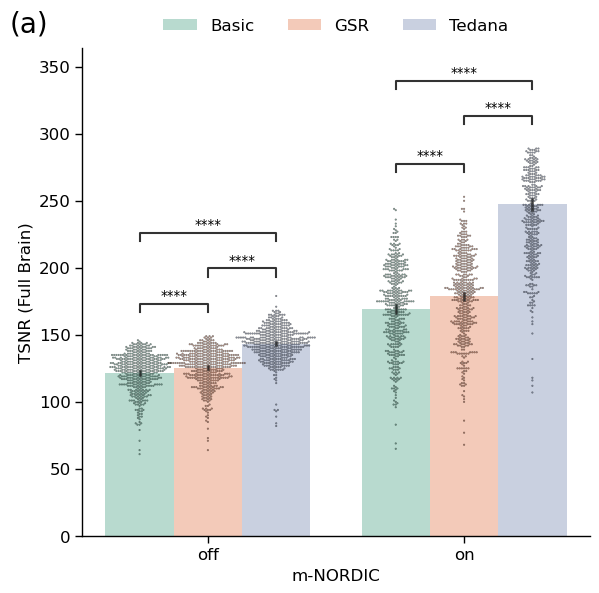

In [25]:
if SES == 'all':
    data_to_show = QC_metrics[FC_METRIC,QC_METRIC].set_index('Pre-processing').loc[SEL_PIPELINES].reset_index()
else:
    idx = pd.IndexSlice
    data_to_show = QC_metrics[FC_METRIC,QC_METRIC].set_index(['Pre-processing','Session']).loc[idx[SEL_PIPELINES, SES], :].reset_index()
panel_a = get_static_report(data_to_show,
                  FC_METRIC,
                  QC_METRIC,  
                  hue='Pre-processing',
                  x='m-NORDIC',
                  stat_test=STAT_TEST, 
                  show_stats=True, 
                  show_points=True,
                  stat_annot_type='star', 
                  remove_outliers_from_swarm=True, 
                  legend_location='lower left', 
                  session=SES, dot_size=1)
panel_a.suptitle("(a)", x=0.01, ha="left", fontsize=20);
panel_a

***
# 5. Create Panel b

Similar to section 4, but this time we work with pBOLD instead of TSNR

In [26]:
QC_METRIC     = 'pBOLD'
SEL_PIPELINES = ['ALL_Basic','ALL_GS','ALL_Tedana-fastica']
STAT_TEST     = 'Mann-Whitney'
SES           = 'all'

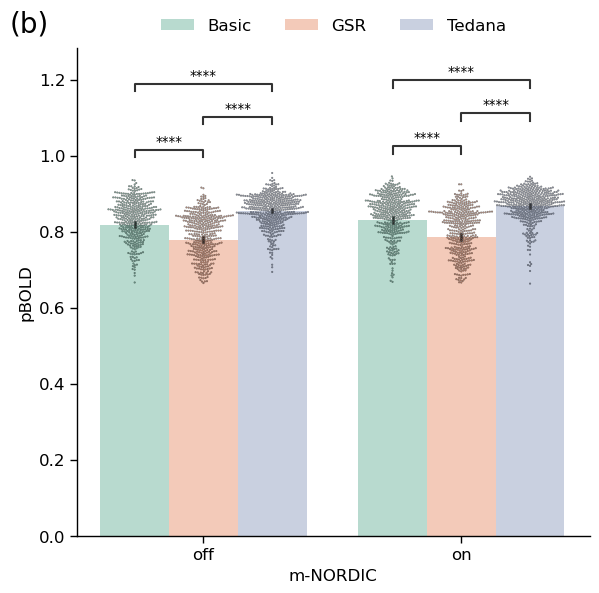

In [27]:
if SES == 'all':
    data_to_show = QC_metrics[FC_METRIC,QC_METRIC].set_index('Pre-processing').loc[SEL_PIPELINES].reset_index()
else:
    idx = pd.IndexSlice
    data_to_show = QC_metrics[FC_METRIC,QC_METRIC].set_index(['Pre-processing','Session']).loc[idx[SEL_PIPELINES, SES], :].reset_index()
panel_b = get_static_report(data_to_show,
                  FC_METRIC,
                  QC_METRIC,  
                  hue='Pre-processing',
                  x='m-NORDIC',
                  stat_test=STAT_TEST, 
                  show_stats=True, 
                  show_points=True,
                  stat_annot_type='star', 
                  remove_outliers_from_swarm=True, 
                  legend_location='lower left', 
                  session=SES, dot_size=1)
panel_b.suptitle("(b)", x=0.01, ha="left", fontsize=20);
panel_b


***
# 6. Putting all together with panel

We now add the top black banner to get the final version of the figure.

In [28]:
import panel as pn

In [29]:
fig_banner = pn.pane.HTML(
    """
    <div style="
        width:100%;
        background:#000;
        color:#fff;
        font-weight:700;
        text-align:center;
        padding:10px 12px;
        box-sizing:border-box;
        font-size:24px;
    ">
      Pre-processing Pipeline Evaluation
    </div>
    """,
    sizing_mode="scale_width",
)

In [30]:
figure04 = pn.Column(fig_banner, pn.Row(panel_a,panel_b), width=1750)

In [31]:
figure04

BokehModel(combine_events=True, render_bundle={'docs_json': {'3b646672-c1c7-4227-ba13-8a9b7e642210': {'version…